# 51_01 — Simulación y preprocesamiento · Escenario TP (tendencia potencia, mezcla)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: *este notebook** genera los datos, ajusta base + FPCA (**sin estandarizar los scores**), escribe los datasets AR
- 02: psbp_fd_iteracion.m muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento 
- 03, 04, 05: `51_03_convergencia` / `51_04_evaluacion` / `51_05_comparacion` 

Nota: Aca solo se simulan los objetos para entrenar en el  muestreador y para ajsutar el FAR en R. 

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [8]:
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioT, generar_escenario_T, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [9]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario_51"
ESCENARIO_ID = 1      # Escenario TP: tendencia potencia (Familia T)
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json
M_FPCA_LIST = (1, 2, 3, 4)

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_51_1_r01
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3, 4]
   M=1  ->  escenario_51_1_r01_m01
   M=2  ->  escenario_51_1_r01_m02
   M=3  ->  escenario_51_1_r01_m03
   M=4  ->  escenario_51_1_r01_m04


In [10]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_51_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_51_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_51_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_51_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_51_1_r01_m01
M=2  (escenario_51_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_51_1_r01_m02
  predict      -> C:\Users\56jua

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

Familia T (`sim_escenario_T`): $Y_t = m(Y_{t-1}, S_t) + \varepsilon_t$,
$X_t = \mu + b_{S_t}(t)\,g(\tau) + Y_t$. `gamma`, `hs_norm`, `sigma_eps` y `ell` son los
parámetros de la parte lineal (operador e innovación), en la celda siguiente.

- `forma_tendencia="potencia"`, `exponente_potencia=1.6`: $b(t)=\text{deriva}\,u^{1.6}$, $u=(t-1)/(T-1)$.
  Con $T_0=0.7T$, $b(T_0)=0.57$ de la deriva total (0.49 cuadrática, 0.34 con p=3, 0.70 lineal).
- `mecanismo="mezcla"`: dos ramas con factor $\pm1$ sobre $\Psi$ y derivas $(1, 0.5)\,b(t)$, mismo signo:
  la tendencia se ve en el nivel y la separación entre modas crece con $t$.
- `inclinacion=0`: deriva de nivel puro.

In [11]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 75    # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 1000    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25    # desviación del ruido de medición

def media_por_tramos(tau):
    """mu(tau) por tramos, continua y con derivada continua (C1).

    Centro [0.3, 0.7]: un ciclo de seno, mu = -A sin(2 pi (tau-0.5)/0.4).
    Extremos [0, 0.3] y [0.7, 1]: parabolas que empalman con el seno en 0.3 y
    0.7 (mismo valor, 0, y misma pendiente) y vuelven a 0 en tau = 0 y tau = 1.
    Resulta impar respecto de (0.5, 0): mu(tau) = -mu(1 - tau).
    """
    tau = np.asarray(tau, dtype=float)
    A = 0.7
    s = 2.0 * np.pi * A / 0.4                       # pendiente del seno en 0.3 y 0.7 (ambas +s)
    centro = -A * np.sin(2.0 * np.pi * (tau - 0.5) / 0.4)
    izq = s * (tau - 0.3) + (s / 0.3) * (tau - 0.3) ** 2
    der = s * (tau - 0.7) - (s / 0.3) * (tau - 0.7) ** 2
    return np.where(tau < 0.3, izq, np.where(tau > 0.7, der, centro))

SIM_CFG = ConfigEscenarioT(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 2000,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_por_tramos,
    # Operador autorregresivo
    gamma     = 0.1,
    hs_norm   = 0.85,
    # Innovación funcional
    sigma_eps = 1.0,
    ell       = 0.5,
    # Tendencia potencia
    forma_tendencia    = "potencia",
    exponente_potencia = 1.6,     # el default del dataclass es 2.0
    deriva             = 6.0,     # nivel medio 0 -> ~4.5 en T (rama media), b(T0)=0.7^1.6=0.57
    inclinacion        = 0.0,     # 0 = deriva de nivel puro
    # Mecanismo
    mecanismo          = "mezcla",
    derivas_regimen    = (1.0, 0.5),  # ramas con tendencia del mismo signo: el nivel SE VE y las modas se separan (1.0 -> 3.0)
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<12}: {v}")

  L           : 75
  T           : 1000
  burn_in     : 2000
  sigma_obs   : 0.25
  R           : 1
  seed        : 41232
  media_fn    : media_por_tramos
  jitter      : 1e-10
  gamma       : 0.1
  hs_norm     : 0.85
  sigma_eps   : 1.0
  ell         : 0.5
  deriva      : 6.0
  forma_tendencia: potencia
  inclinacion : 0.0
  ciclos_sinusoidal: 1.5
  amplitud_sinusoidal: 0.15
  curvatura_log: 9.0
  exponente_potencia: 3.0
  curvatura_exponencial: 3.0
  centro_logistica: 0.5
  pendiente_logistica: 10.0
  fraccion_escalon: 0.6
  tramos_tendencia: None
  volatilidad_tendencia: 0.0
  persistencia_volatilidad: 0.95
  mecanismo   : mezcla
  interacciones: ((0.25, 0.75), (0.5, 0.5))
  pesos_interaccion: (1.0, 1.0)
  ancho_lectura: 0.1
  ancho_respuesta: 0.15
  razon_interaccion: 0.6
  saturacion  : 3.0
  factores_operador: (1.0, -1.0)
  derivas_regimen: (1.0, 0.5)
  formas_regimen: None
  nitidez     : 4.0
  umbral      : 0.0
  umbrales    : None
  direccion_fn: None
  n_dim_diagnostico: 5
  

### 2.2 Generación

In [12]:
salida = generar_escenario_T(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")

Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2503   (nominal 0.25)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = 1.1657606337609474
  media_ee_montecarlo              = nan
  var_puntual_media                = 3.5063320390270225
  var_puntual_min                  = 3.1426168343348913
  var_puntual_max                  = 3.630363270315345
  acf1_media                       = 0.5664023317716926
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 56.10131262443236
  hs_norm_objetivo                 = 0.85
  hs_norm_efectiva                 = 0.85
  radio_espectral                  = 0.5008488161271968
  estacionariedad_garantizada      = False
  motivo_no_estacionario           = tendencia determinista en t (por

In [13]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_51_1_r01_m04\escenario_1.npz


### 2.3 Visualización de los datos

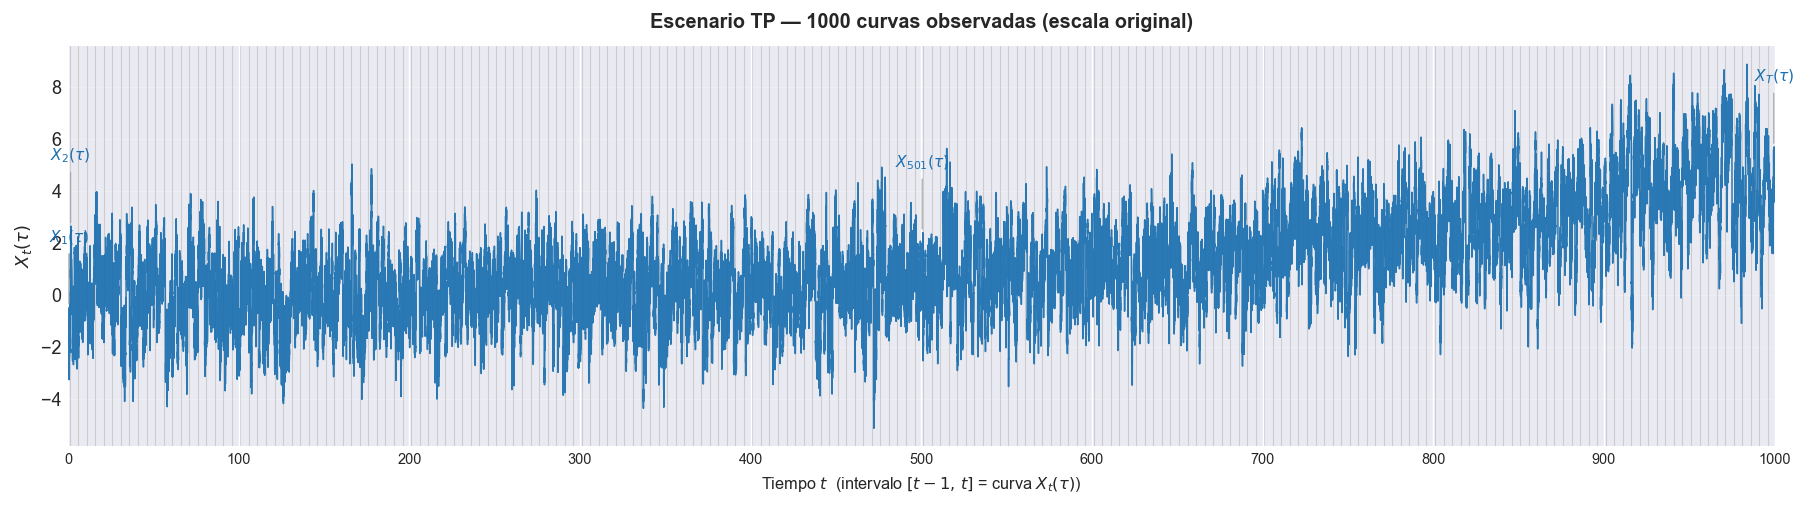

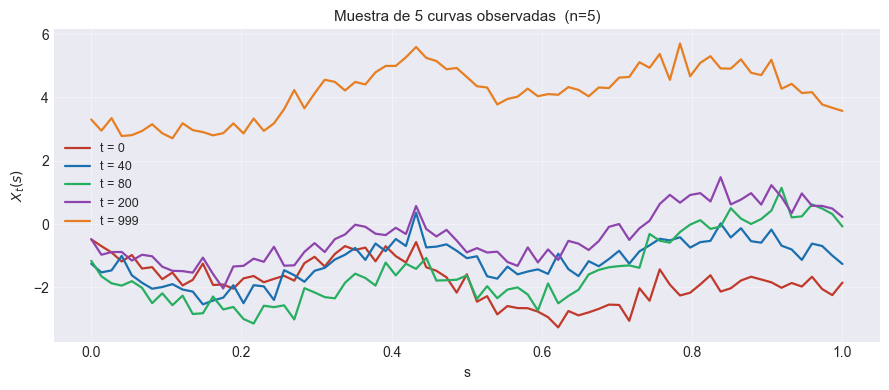

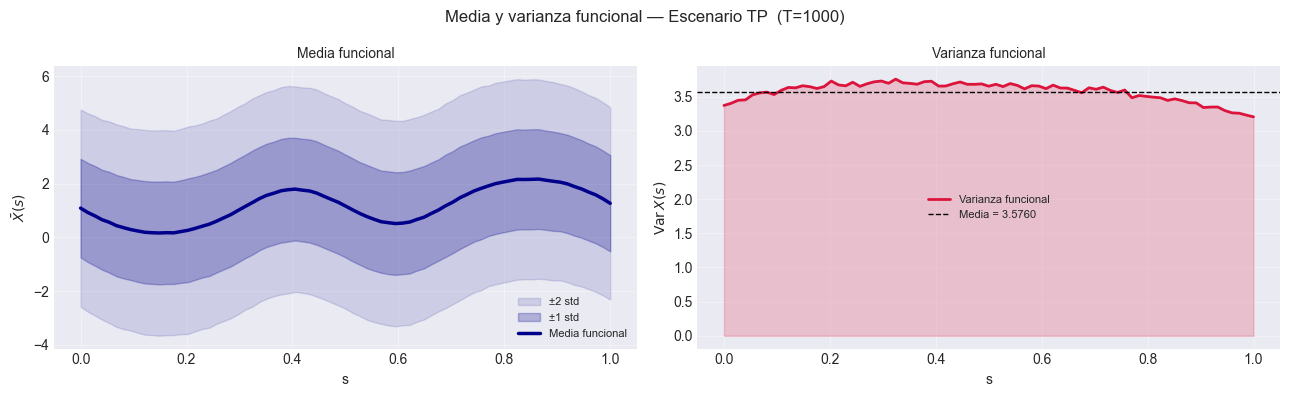

In [14]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario TP — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario TP")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

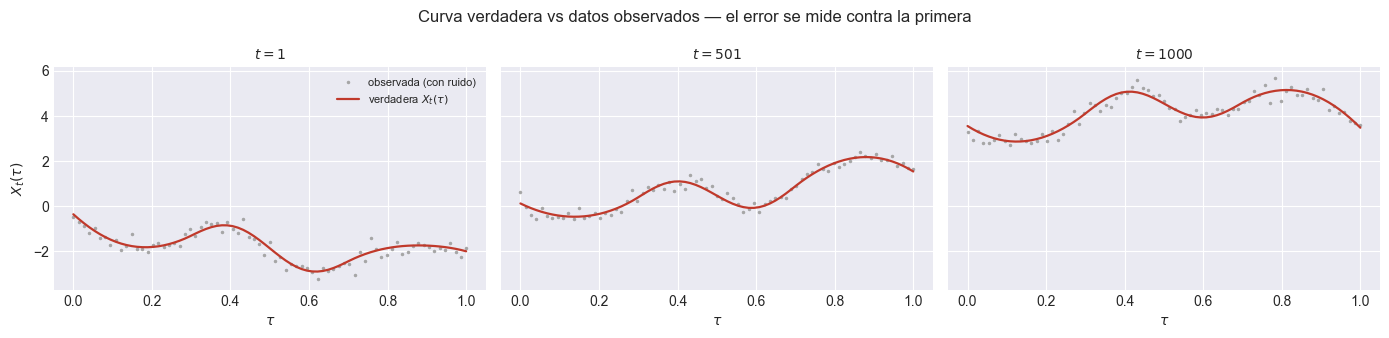

In [15]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [16]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 4 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 4 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 4 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [17]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,80.6715%,0.569554,0.913840,0.346410
1,3,2,83.5428%,0.527682,0.635168,0.303200
2,4,2,85.2814%,0.498336,0.641835,0.278862
3,5,2,84.2400%,0.516471,0.619514,0.307183
4,6,2,95.9737%,0.260578,0.318236,0.080769
5,7,2,94.3276%,0.309336,0.378475,0.117163
6,8,2,96.1164%,0.255882,0.321424,0.082627
7,9,2,96.4075%,0.246095,0.313788,0.078767
8,10,2,96.5357%,0.241636,0.308173,0.078312
9,11,2,96.7181%,0.235209,0.298200,0.076525



GCV mínimo → n_basis=8, order=3  (var retenida 96.6342%)


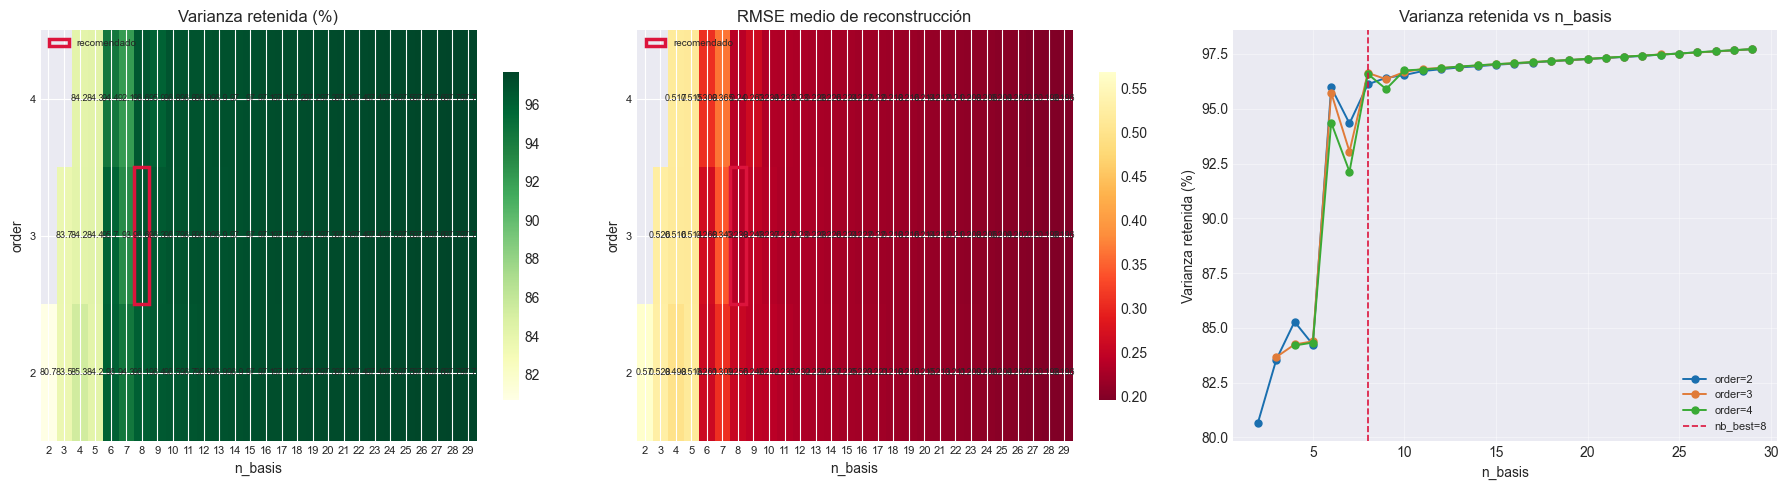

In [18]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=8, order=3
Sugerido GCV : n_basis=8, order=3   (coinciden)
THETA (1000, 8)  (train=700, test=300)


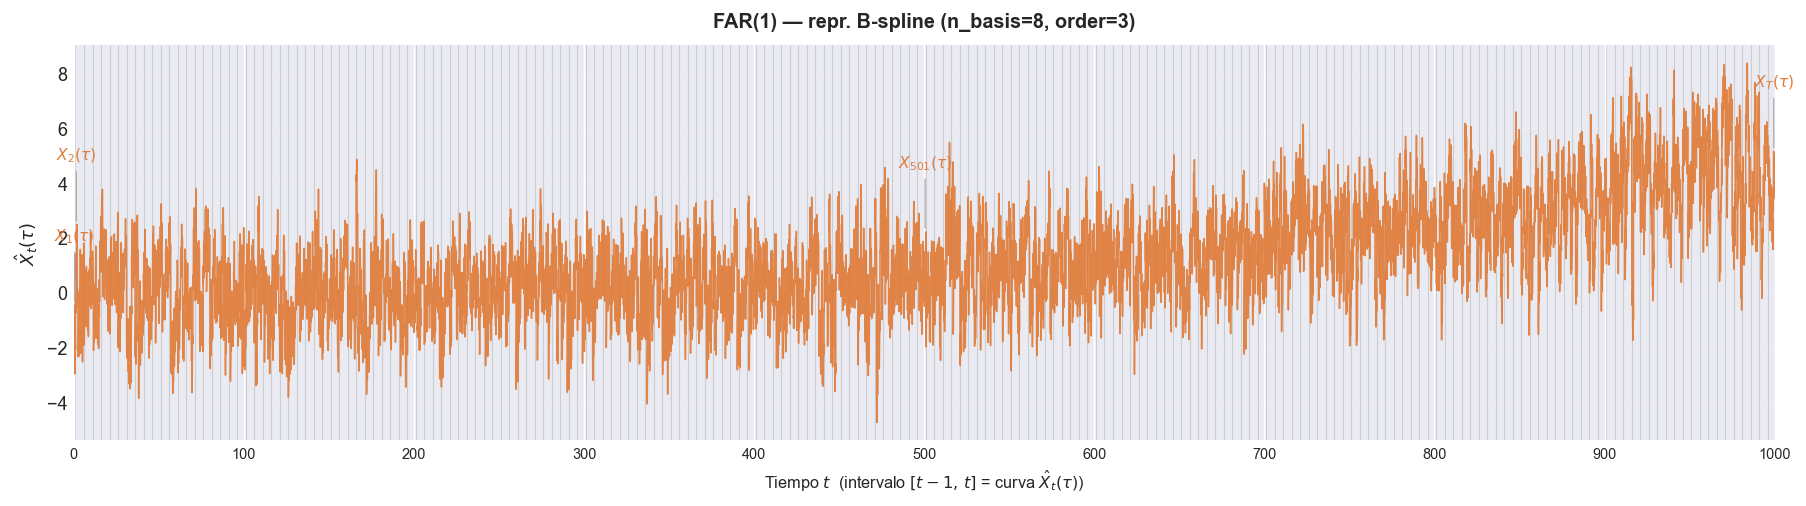

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 4 directorios)


In [19]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [20]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 8
  K                                  = 8
  n_ajuste                           = 700
  cond_W                             = 1.027e+01
  err_ortonormalidad_L2              = 1.910e-15
  err_ortonormalidad_gram            = 1.863e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.273e-16
  err_media_scores_rel               = 1.932e-15
  err_var_scores_vs_lambda           = 2.220e-15
  err_var_scores_vs_lambda_rel       = 7.373e-14
  err_correlacion_lag0               = 4.859e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,1.3898e+00,84.3207%,84.3207%,+0.235
1,2,2.1581e-01,13.0936%,97.4143%,+0.128
2,3,3.4102e-02,2.0690%,99.4833%,+0.095
3,4,4.1095e-03,0.2493%,99.7326%,+0.058
4,5,1.8083e-03,0.1097%,99.8423%,+0.031
5,6,9.5985e-04,0.0582%,99.9006%,+0.002
6,7,8.4114e-04,0.0510%,99.9516%,+0.009
7,8,7.9754e-04,0.0484%,100.0000%,+0.053



K disponibles: 8   ·   sugerencia (var ≥ 95%): M = 2
  M=1: var. acum = 84.3207%  ·  sensibilidad
  M=2: var. acum = 97.4143%  ·  regla del 95 %
  M=3: var. acum = 99.4833%  ·  sensibilidad
  M=4: var. acum = 99.7326%  ·  sensibilidad


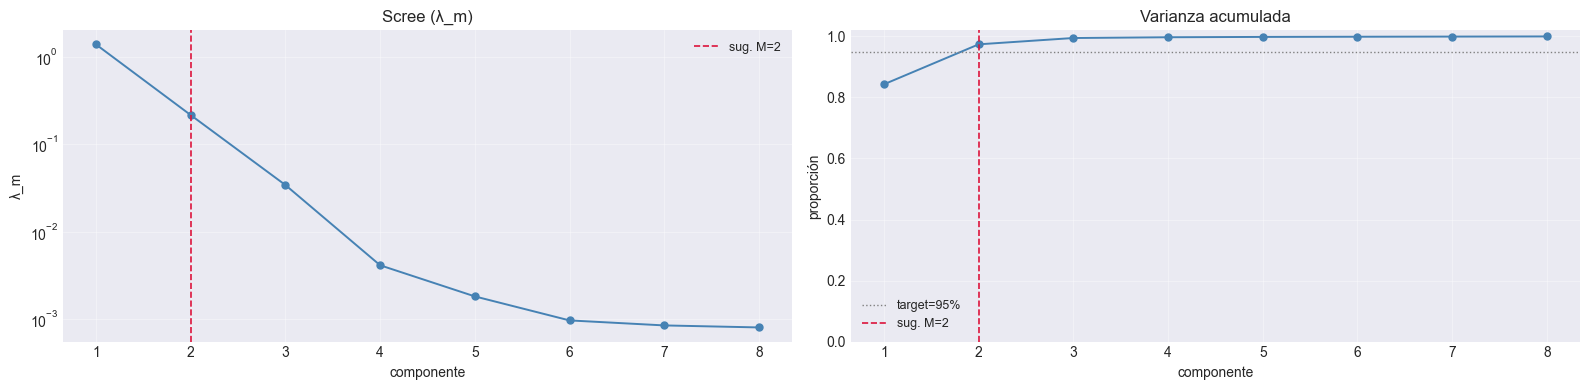

In [21]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA
- Se ven todos. 

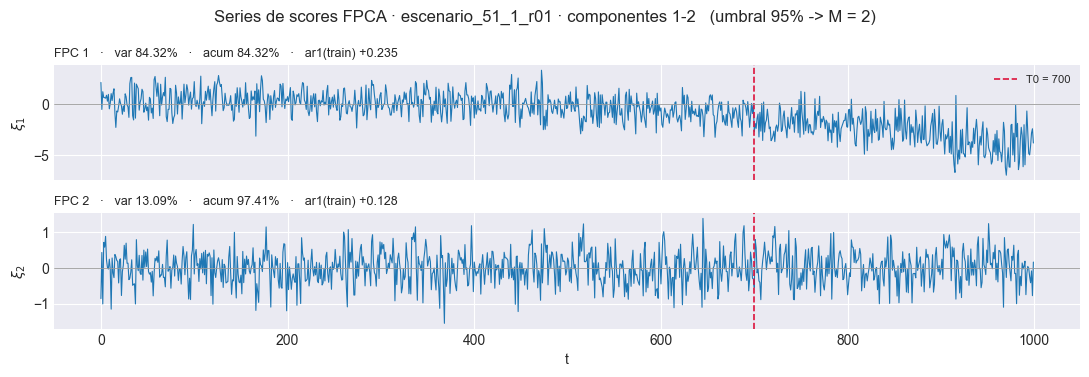

componentes graficadas : 1-2  de K = 8
var. acumulada hasta 2 : 97.4143%


In [22]:
# [CONFIG] §3.4 — hasta que componente se grafica. Por defecto, la que fija el
# umbral VAR_TARGET de la celda anterior; subirlo mira mas alla de la regla.
N_SERIES_SCORES = M_SUGERIDO

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI[:, k], lw=0.8, color="C0")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(rf"$\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   var {fpca.var_ratio[k]:.2%}   ·   "
                 f"acum {fpca.var_cum[k]:.2%}   ·   ar1(train) {ar1[k]:+.3f}",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Series de scores FPCA · {EXPERIMENT_BASE} · componentes 1-"
             f"{N_SERIES_SCORES}   (umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
fig.tight_layout()
replicar_figura("07b_fpca_scores_series.png", PATHS_POR_M)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}"
      + ("" if N_SERIES_SCORES == M_SUGERIDO
         else f"   <- DIFIERE del umbral (M_SUGERIDO = {M_SUGERIDO})"))
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")


### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó, no lo que se entrega.

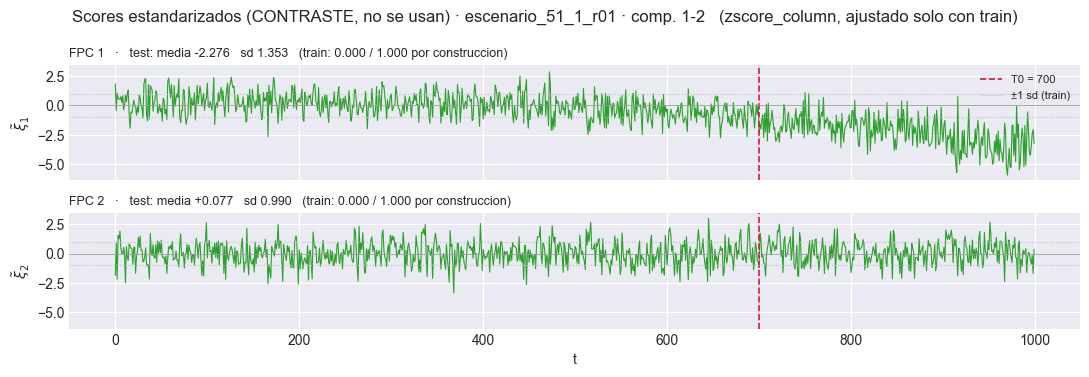

escala original  sd(train) : [1.1781 0.4642]
estandarizado    sd(test)  : [1.3534 0.9905]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [23]:
# §3.5 — mismo grafico que §3.4 pero estandarizando. CONTRASTE: NO es lo que
# se entrega. El pipeline usa los scores crudos; esto es la alternativa
# descartada, que se mira para saber cuanto cambia la escala.
_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")


## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA 
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [24]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train y se registra n_ajuste igual, porque verificar_contrato
    # exige n_ajuste == T0. Lo que NO se hace es aplicarlo: ver abajo.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    # SIN ESTANDARIZAR MATLAB recibe los scores en su ESCALA PROPIA. El objeto
    # no se elimina
    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]"
          "   <- de ahi sale la grilla G* y con ella la escala del gating")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC
    # Escala del argumento probit. v_h(x) = Phi(alpha_h - sum_j psi_hj |x_j - Gamma_hj|)
    # crece LINEALMENTE en p y con la amplitud de G*, de modo que con los scores
    # SIN estandarizar mupsij no se puede fijar a mano: se despeja de
    # arg_objetivo. Se replica la grilla G* de psbp_train.m (min/max GLOBALES de
    # Xnoint, no por columna) y el sorteo de Gammajh sobre ella.
    _Xn      = np.vstack([dfs_train[k][cov_names].to_numpy() for k in range(n_components)])
    _lo, _hi = float(_Xn.min()), float(_Xn.max())
    _Gstar   = _lo + (np.arange(1, MCMC_CONFIG["M"] + 1) / MCMC_CONFIG["M"]) * (_hi - _lo)
    _rng_cal = np.random.default_rng(SEED)
    _Gam     = _rng_cal.choice(_Gstar, size=(MCMC_CONFIG["N"] - 1, len(cov_names)))
    ESCALA_PROBIT = float(np.abs(_Xn[None, :, :] - _Gam[:, None, :]).sum(-1).mean())

    print(f"\nG* = [{_lo:.3f}, {_hi:.3f}]   E[sum_j |x_j - Gamma_j|] = {ESCALA_PROBIT:.3f}")

    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    # apij/bpij salen de HP_BY_TYPE, no de la escalera: lo que los ordena es el
    # TIPO de rezago, no k. Lo demas de la escalera sigue siendo por componente.
    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    # Tasa de escape del estado w_j = 0, que es ABSORBENTE: con w_j = 0 queda
    # pij = 0 (psbp_train.m:221) y entonces ajhin lleva log(realmin) ~ -708
    # (psbp_train.m:320), asi que ningun gamma_hj de los N atomos puede volver a
    # 1. La unica salida es la moneda de psbp_train.m:202, con probabilidad
    #     pwj * b_val / ((1-pwj) + pwj * b_val),
    #     b_val = B(apij, bpij+N) / B(apij, bpij)  ~  Gamma(a+b)/Gamma(b) N^-apij
    # que decae como N^(-apij): apij es el EXPONENTE. Con apij=bpij=5 y N=35 da
    # 1.2e-4, o sea 8600 iteraciones de espera sobre cadenas de 2500 -> w_j nunca
    # vuelve. Medido en la corrida 50_c: la mayoria de las covariables cruzadas
    # tienen UN solo flip y se quedan en cero hasta el final, y las dos cadenas
    # caen en iteraciones distintas -> R-hat de p_j hasta 2.94 con beta_j en
    # 1.000. Con apij = 1 se cierra en forma: escape = bpij/(bpij+N).
    def _escape(apij, bpij, pwj, N):
        b_val = math.exp(math.lgamma(bpij + N) + math.lgamma(apij + bpij)
                         - math.lgamma(bpij) - math.lgamma(apij + bpij + N))
        return pwj * b_val / ((1 - pwj) + pwj * b_val)

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc      = HP_ESCALERA[k]
        mupsij_k = esc["arg_objetivo"] / ESCALA_PROBIT
        _ab      = [_beta_pi(nm, k) for nm in cov_names]

        # btau se despeja de E[tau] y del atau del peldano: btau = atau / E[tau].
        # NO hay piso. tau_h es la precision residual DE CADA ATOMO, y la cota
        # var(residuo) <= var(y) sale de la ley de varianza total
        #     lambda_k = E_h[var(y|h)] + var_h(E[y|h])
        # que acota el PROMEDIO sobre la mezcla, no cada atomo: uno puede ser mas
        # disperso que la serie entera si otros son mas concentrados. Medido en
        # la corrida anterior, entre 8 % y 15 % de los atomos ocupados quedan por
        # debajo de 1/lambda_k, y la media de 1/tau_h dio 0.174 contra
        # lambda = 0.330, o sea el promedio SI respeta la cota.
        # 1/lambda_k se imprime como ESCALA de referencia -tau vive en unidades
        # de 1/var(y)- y por eso un E[tau] no se puede copiar de una corrida con
        # scores estandarizados, donde var(y) = 1. No es una restriccion.
        var_y_k = float(SCORES_train[:, k].var(ddof=0))
        E_tau_k = float(esc["e_tau_objetivo"])
        btau_k  = esc["atau"] / E_tau_k

        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": float(esc["atau"]), "btau": float(btau_k),
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.full(len(cov_names), mupsij_k,       dtype=float),
            "taupsij": np.full(len(cov_names), esc["taupsij"], dtype=float)})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    print(f"  {'k':>2} {'fpc':>4} {'arg':>6} {'mupsij':>9} {'taupsij':>8} "
          f"{'Etau ped':>9} {'var(y)':>8} {'1/var':>7} {'E[tau]':>8} {'btau':>8}")
    for k in range(n_components):
        hp, esc = HYPERPARAMS_LIST[k], HP_ESCALERA[k]
        _v = float(SCORES_train[:, k].var(ddof=0))
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {esc['arg_objetivo']:>6.2f} "
              f"{hp['mupsij'][0]:>9.5f} {hp['taupsij'][0]:>8.1f} "
              f"{esc['e_tau_objetivo']:>9.1f} {_v:>8.4f} {1/_v:>7.2f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>8.5f}")

    # apij/bpij por covariable + la espera esperada para que w_j vuelva de 0.
    print(f"\n  {'k':>2} {'covariable':>16} {'tipo':>10} {'apij':>6} {'bpij':>6} "
          f"{'E[pi]':>7} {'P(escape)':>10} {'espera':>8}")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            pe   = _escape(a, b, HP_GLOBAL["pwj"], MCMC_CONFIG["N"])
            flag = "  <- > nsim" if 1 / pe > MCMC_CONFIG["nsim"] else ""
            print(f"  {k:>2} {nm:>16} {_clasificar(nm, k):>10} {a:>6.3f} {b:>6.3f} "
                  f"{a/(a+b):>7.3f} {pe:>10.2e} {1/pe:>8.0f}{flag}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "escalera":     {str(k): HP_ESCALERA[k] for k in range(n_components)},
        "escala_probit": ESCALA_PROBIT,
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
        #   curva_verdadera + modo_residuo "ninguno"
        "objetivo_evaluacion": "curva_verdadera",
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_true, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva VERDADERA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }


escalera por componente (btau se despeja en procesar_punto):
   k    arg  taupsij   apij   bpij   E[pi]   atau  E[tau]
   0   2.00      0.5    5.0    5.0   0.500   2.50    10.0
   1   1.50      1.0    5.0    5.0   0.500   2.00    10.0
   2   1.00      2.0    5.0    5.0   0.500   1.50     5.0
   3   1.00      2.0    5.0    5.0   0.500   1.00     5.0
N_LAGS      : 1
MCMC_CONFIG : {'nsim': 4000, 'burn': 2000, 'N': 35, 'M': 50}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (4000 - 2000) x 2 = 4000

M = 1   ·   escenario_51_1_r01_m01
M(95 %) según la regla : 2   (K disponible = 8)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 84.3207%
[train] max|media xi| = 1.83e-16   (~ 0)
[test]  max|media xi| = 2.681
[test]  var xi / lambda = [1.835]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 1)   (= SCORES: transformacion identidad)
  [train] media = [1.827e-

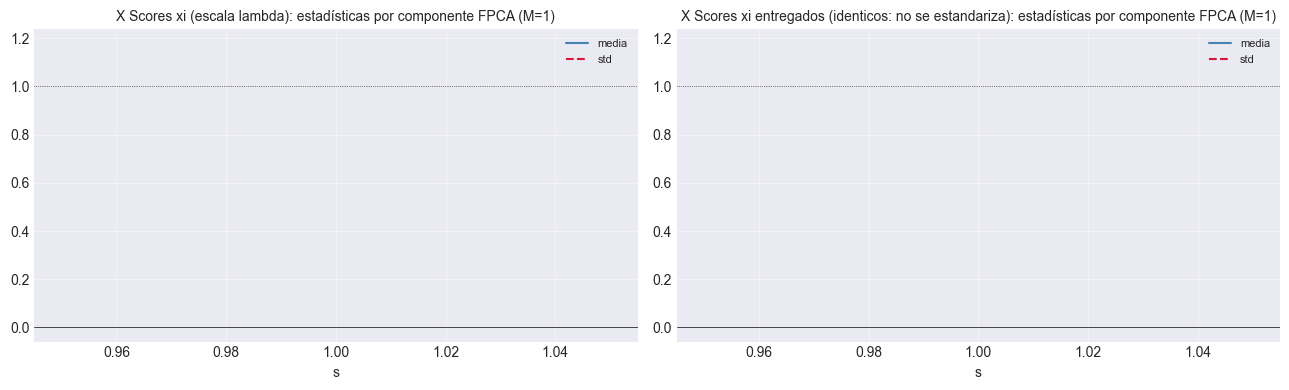

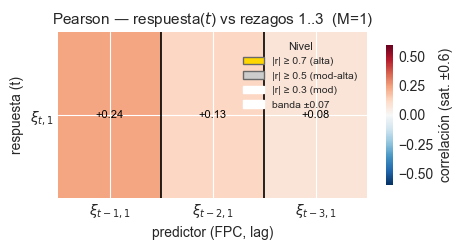

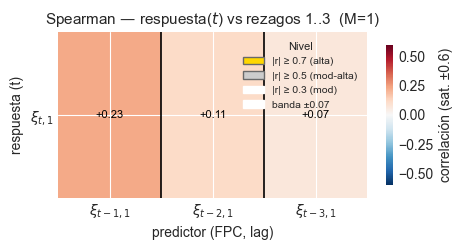

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 699   n_test_eff : 300
cov_names   : ['fpc_1_lag1']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (699, 2) · test (300, 2)

G* = [-3.255, 3.352]   E[sum_j |x_j - Gamma_j|] = 1.986

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij   E[pi]  Etau ped   var(y)   1/var   E[tau]     btau
   0    1   2.00   1.00685      0.5   0.500      10.0   1.3878    0.72    10.00  0.25000
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_51_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,3.1191,3.1191,-2.8274,10.0629,3.1722
persistencia_lag1,300.0000,1.9358,1.9358,-0.4742,4.0805,2.0200


contrato_ok = True   (M=1, K=8, T0=700, n_components=1)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_51_1_r01_m02
M(95 %) según la regla : 2   (K disponible = 8)
M de este punto        : 2   (coincide con la regla)
M = 2   var. explicada = 97.4143%
[train] max|media xi| = 2.27e-16   (~ 0)
[test]  max|media xi| = 2.681
[test]  var xi / lambda = [1.835 0.983]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 2)   (= SCORES: transformacion identidad)
  [train] media = [ 2.273e-16 -7.748e-17]   <- NO se resta
  [train] std   = [1.178 0.464]   <- NO se divide
  [test]  media = [-2.681  0.036]
  [test]  std   = [1.594 0.46 ]
  rango que vera MATLAB: [-6.992, 3.352]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 1.027e+01


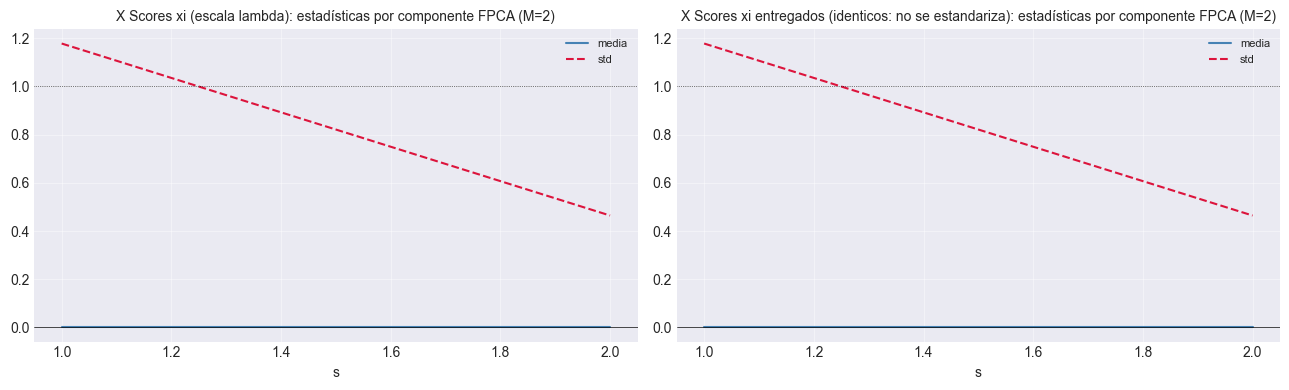

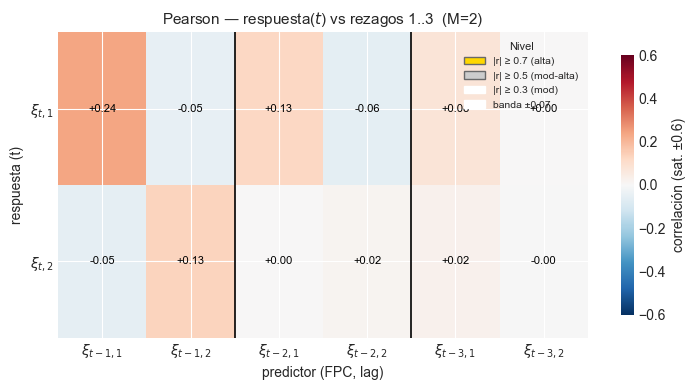

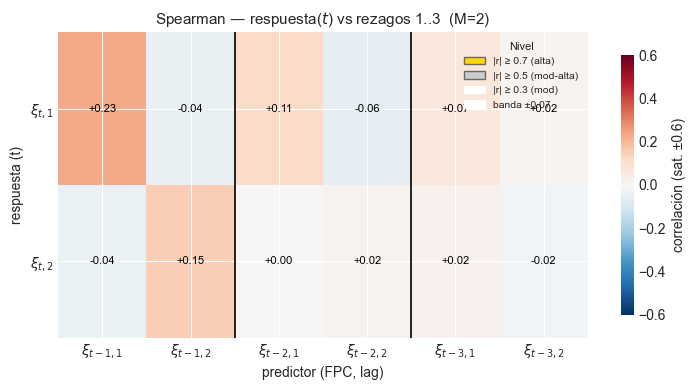

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 699   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (699, 3) · test (300, 3)
  fpc_2: train (699, 3) · test (300, 3)

G* = [-3.255, 3.352]   E[sum_j |x_j - Gamma_j|] = 4.183

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij   E[pi]  Etau ped   var(y)   1/var   E[tau]     btau
   0    1   2.00   0.47814      0.5   0.500      10.0   1.3878    0.72    10.00  0.25000
   1    2   1.50   0.35860      1.0   0.500      10.0   0.2155    4.64    10.00  0.20000
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_51_1_r01_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,3.1191,0.4612,1.7902,-1.4167,10.0629,3.1722
persistencia_lag1,300.0000,1.9358,0.5889,1.2623,-0.5573,4.2132,2.0526


contrato_ok = True   (M=2, K=8, T0=700, n_components=2)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_51_1_r01_m03
M(95 %) según la regla : 2   (K disponible = 8)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 99.4833%
[train] max|media xi| = 2.27e-16   (~ 0)
[test]  max|media xi| = 2.681
[test]  var xi / lambda = [1.835 0.983 1.361]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 3)   (= SCORES: transformacion identidad)
  [train] media = [ 2.273e-16 -7.748e-17  2.139e-16]   <- NO se resta
  [train] std   = [1.178 0.464 0.185]   <- NO se divide
  [test]  media = [-2.681  0.036  0.272]
  [test]  std   = [1.594 0.46  0.215]
  rango que vera MATLAB: [-6.992, 3.352]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 1.027e+01


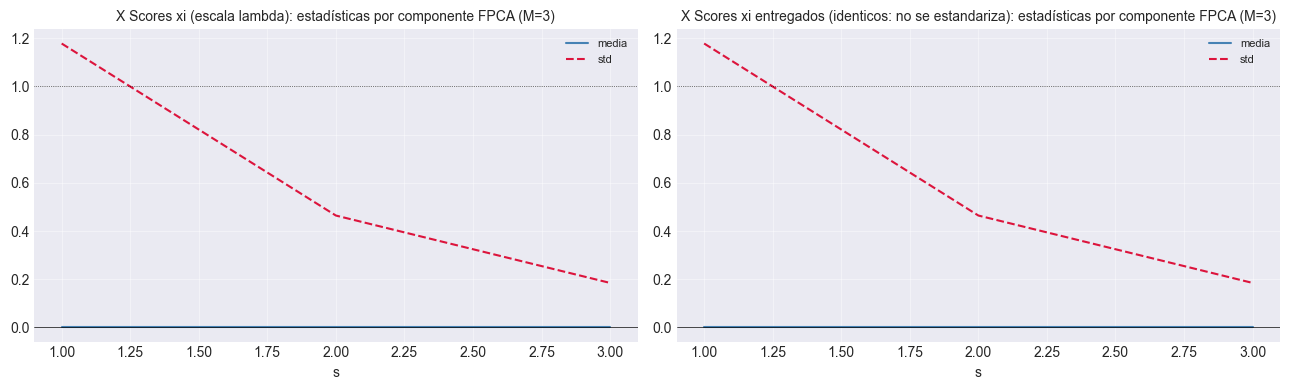

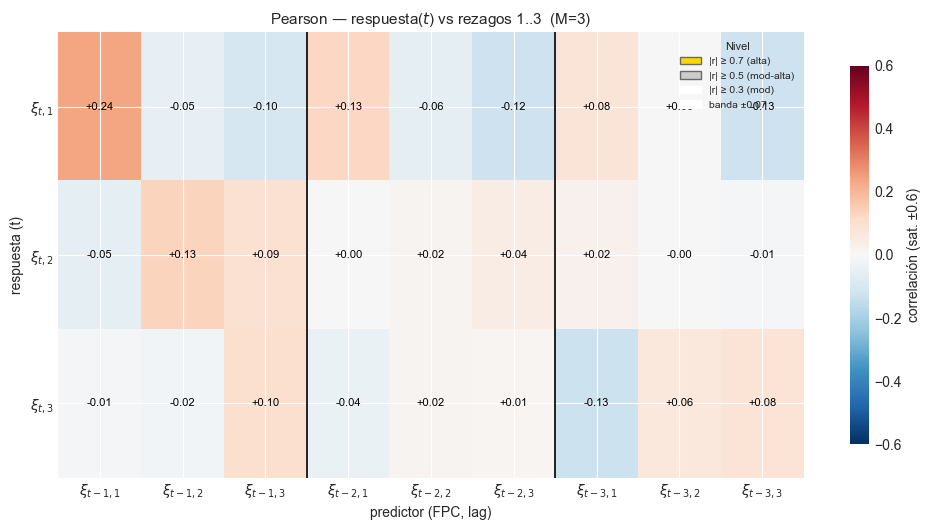

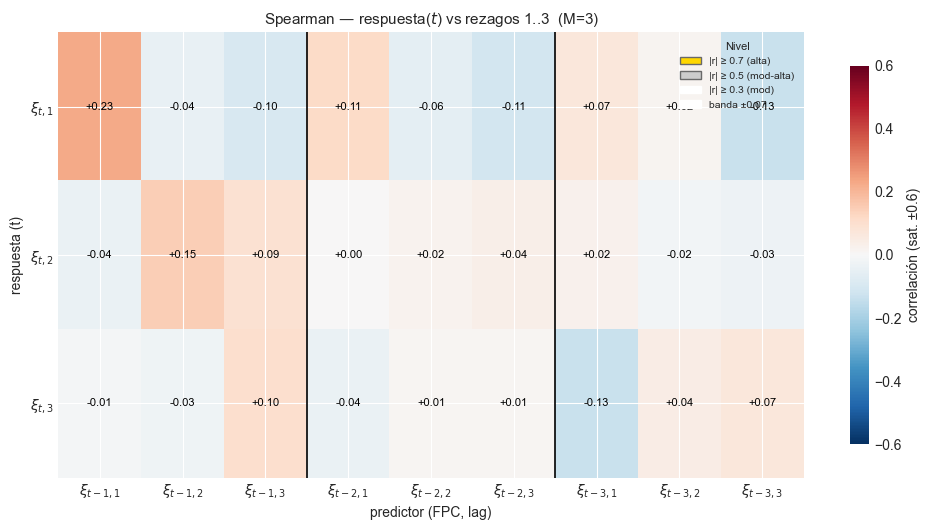

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 699   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (699, 4) · test (300, 4)
  fpc_2: train (699, 4) · test (300, 4)
  fpc_3: train (699, 4) · test (300, 4)

G* = [-3.255, 3.352]   E[sum_j |x_j - Gamma_j|] = 6.022

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij   E[pi]  Etau ped   var(y)   1/var   E[tau]     btau
   0    1   2.00   0.33209      0.5   0.500      10.0   1.3878    0.72    10.00  0.25000
   1    2   1.50   0.24907      1.0   0.500      10.0   0.2155    4.64    10.00  0.20000
   2    3   1.00   0.16605      2.0   0.500       5.0   0.0341   29.37     5.00  0.30000
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_51_1_r01_m03
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,3.1191,0.4612,0.3471,1.3091,-1.4793,10.0629,3.1722
persistencia_lag1,300.0000,1.9358,0.5889,0.2665,0.9304,-0.5500,4.1621,2.0401


contrato_ok = True   (M=3, K=8, T0=700, n_components=3)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 4   ·   escenario_51_1_r01_m04
M(95 %) según la regla : 2   (K disponible = 8)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 99.7326%
[train] max|media xi| = 2.27e-16   (~ 0)
[test]  max|media xi| = 2.681
[test]  var xi / lambda = [1.835 0.983 1.361 1.049]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 4)   (= SCORES: transformacion identidad)
  [train] media = [ 2.273e-16 -7.748e-17  2.139e-16  1.239e-16]   <- NO se resta
  [train] std   = [1.178 0.464 0.185 0.064]   <- NO se divide
  [test]  media = [-2.681  0.036  0.272  0.005]
  [test]  std   = [1.594 0.46  0.215 0.066]
  rango que vera MATLAB: [-6.992, 3.352]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 1.027e+01


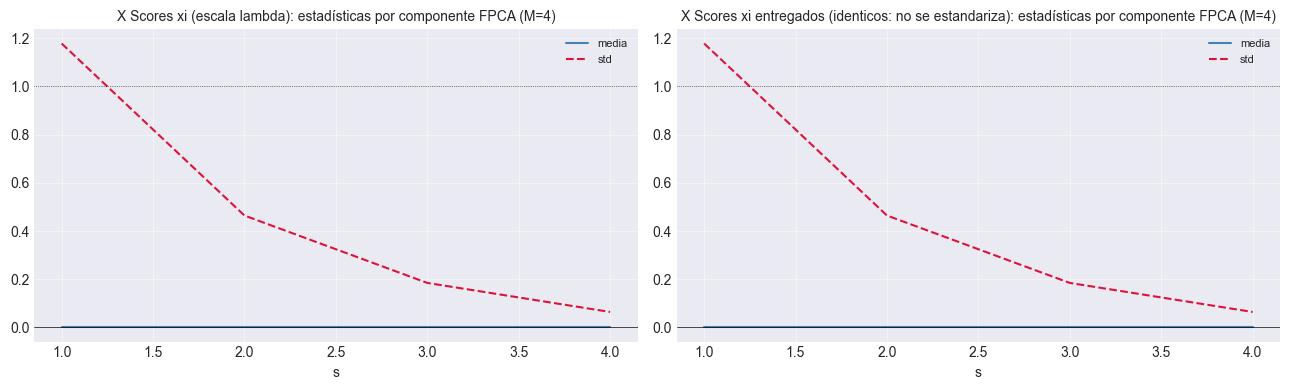

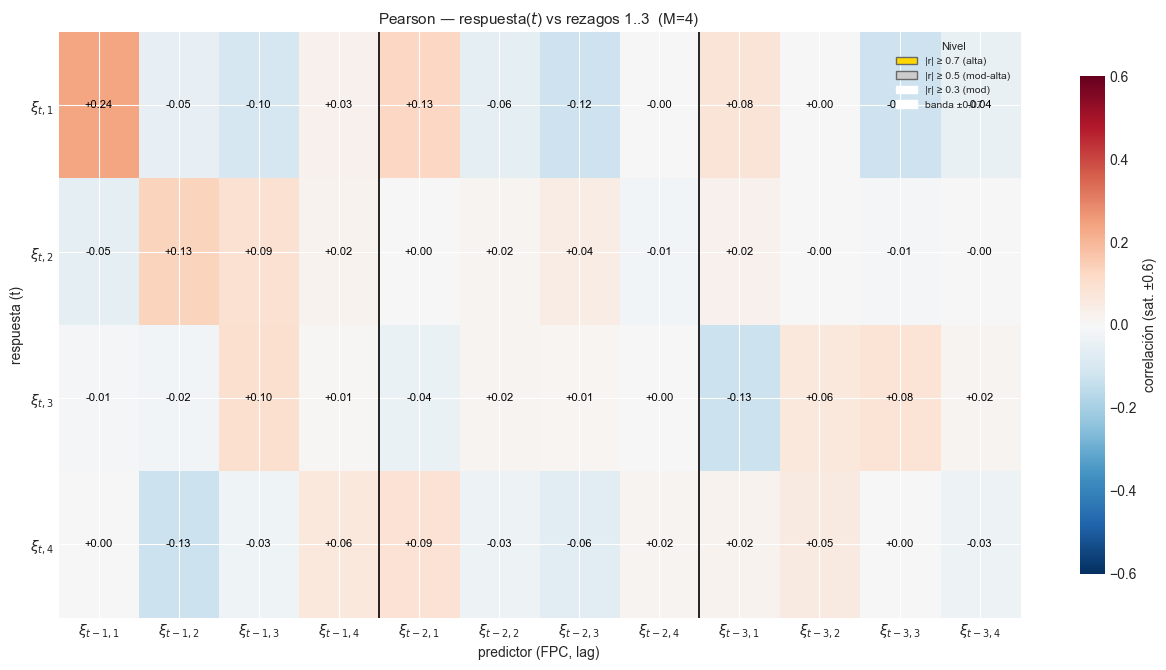

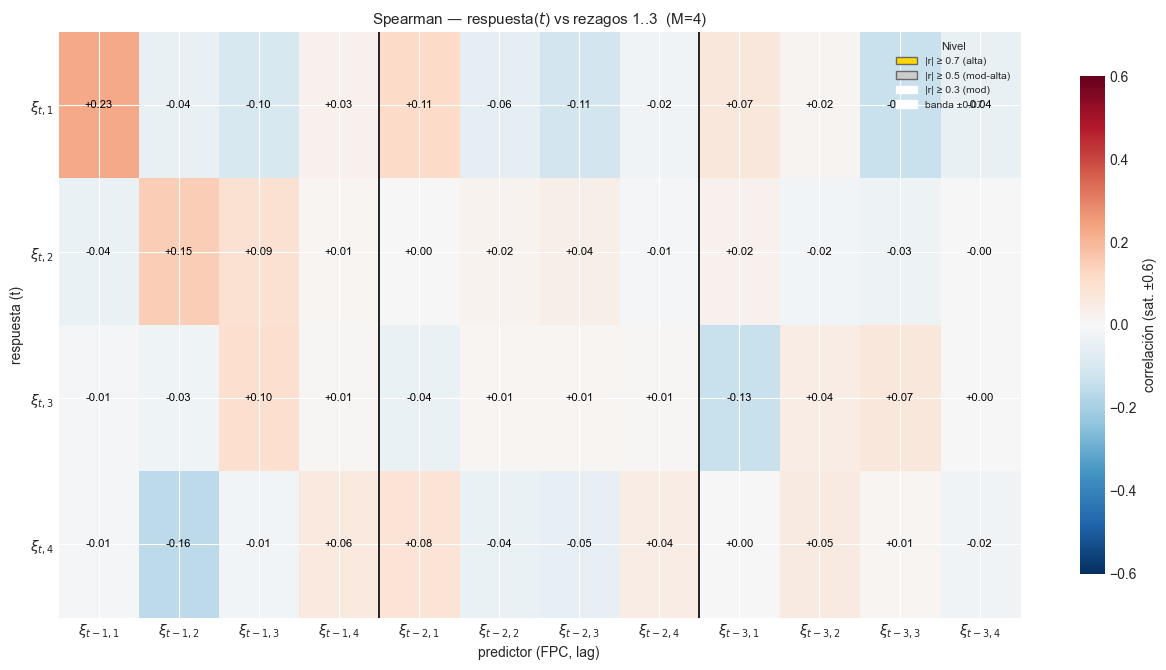

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 1   ·   p = 4 covariables
n_train_eff : 699   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1']
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (699, 5) · test (300, 5)
  fpc_2: train (699, 5) · test (300, 5)
  fpc_3: train (699, 5) · test (300, 5)
  fpc_4: train (699, 5) · test (300, 5)

G* = [-3.255, 3.352]   E[sum_j |x_j - Gamma_j|] = 7.546

N_CHAINS = 2 cadenas por componente -> 8 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij   E[pi]  Etau ped   var(y)   1/var   E[tau]     btau
   0    1   2.00   0.26503      0.5   0.500      10.0   1.3878    0.72    10.00  0.25000
   1    2   1.50   0.19877      1.0   0.500      10.0   0.2155    4.64    10.00  0.20000
   2    3   1.00   0.13252      2.0   0.500       5.0   0.0341   29.37     5.00  0.30000
   3    4   1.00   0.13252      2.0   0.500       5.0   0.0041  243.69     5.00  0.20000
[out_artefact] hyperparameters.j

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,3.1191,0.4612,0.3471,0.0657,0.9983,-1.1109,10.0629,3.1722
persistencia_lag1,300.0000,1.9358,0.5889,0.2665,0.0947,0.7215,-0.6847,4.1663,2.0411


contrato_ok = True   (M=4, K=8, T0=700, n_components=4)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True


In [25]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 1
MCMC_CONFIG = {"nsim": 2500, "burn": 1000, "N": 35, "M": 50}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors de INCLUSION por tipo de covariable. apij/bpij ya NO estan en la
# escalera: lo que los ordena es el tipo de rezago, no el componente k.
#
# apij = 1 en los dos por una razon de MEZCLA, no de encogimiento. w_j = 0 es un
# estado absorbente (ver la seccion w_j abajo) y la tasa de escape decae como
# N^(-apij). Con apij = 1 se cierra en forma:
#       E[pi] = 1/(1+bpij)          escape = bpij/(bpij+N)     [con pwj=0.5]
# o sea que E[pi] alto y escape rapido son OPUESTOS, y bpij elige el punto.
#
#   own_lag1   bpij=1/9 -> E[pi]=0.90, escape cada 316 iter. Lento a proposito:
#              el propio rezago no se quiere excluir nunca, y medido en 50_c
#              nunca se apago (flips=0 en las dos cadenas). Si igual cae, tarda.
#   cross_lag  bpij=5   -> E[pi]=0.167, escape cada 9 iter. Son los valores de
#              Chung & Dunson (references/Case1_01.m:35) y son los que se
#              apagaban y no volvian.
HP_BY_TYPE = {
    "own_lag1":  {"apij": 1.0, "bpij": 1.0 / 9.0},
    "cross_lag": {"apij": 1.0, "bpij": 5.0},
}

# ############################################################################
# EL MODELO, Y DONDE ENTRA CADA CONSTANTE
# ############################################################################
# Un PSBP univariado por componente FPCA: y_i = score k en t, x_i = sus rezagos.
#
#   ATOMO      y_i | S_i = h  ~  N( b0_h + x_i' b_h ,  1/tau_h )
#   MEZCLA     v_h(x) = Phi( alpha_h - sum_j psi_hj * |x_j - Gamma_hj| )
#              pi_h(x) = v_h(x) * prod_{l<h} (1 - v_l(x))          (stick-breaking)
#
#   PRIORS     tau_h   ~ Gamma(atau, btau)                 <- atau, btau
#              b_h     ~ N( 0, (n/g) (X_h'X_h)^-1 / tau_h )   g-prior
#              g       ~ Gamma(ag, bg)                     <- ag, bg
#              alpha_h ~ N(mu, 1),  mu ~ N(mumu, 1/taumu)  <- mumu, taumu
#              psi_hj  ~ N_+(mupsij_j, 1/taupsij_j)        <- mupsij, taupsij
#                        truncada a [0,inf), y = 0 si gamma_hj = 0
#              Gamma_hj~ Unif{G*},  G* = M puntos en [min(X), max(X)]  <- M
#              gamma_hj~ Bern(pi_j),  pi_j ~ Beta(apij_j, bpij_j)  <- apij, bpij
#              w_j     ~ Bern(pwj)                         <- pwj
#              h = 1..N                                    <- N (truncamiento)
#
# ############################################################################
# TABLA DE REFERENCIA
# Chung & Dunson (references/Case1_01.m:33-50) corren sobre datos
# ESTANDARIZADOS (lineas 16-20: y y X con media 0 y sd 1 del bloque de ajuste).
# Aqui los scores van CRUDOS, con var(y_k) = lambda_k = 0.330 0.258 0.221 0.146.
# Por eso las constantes en unidades de y -atau/btau- NO son comparables
# directamente; las adimensionales -apij/bpij, ag/bg, pwj- si lo son.
# ############################################################################
#
#  cte        formula           Chung        aqui (k=0..3)      SUBE -> / BAJA ->
#  --------------------------------------------------------------------------
#  N       h = 1..N               20        35            mas atomos disponibles
#                                                         (coste O(N)) / la
#                                                         mezcla se trunca y
#                                                         pierde modos
#  M       |G*|                   50        50            grilla de Gamma mas
#                                                         fina / Gamma mas
#                                                         grueso, gating tosco
#  atau    Gamma(atau,btau)      0.5        2.5 2 1.5 1   prior de tau mas
#                                                         pesado (2*atau obs) y
#                                                         concentrado / mas
#                                                         plano, mandan datos
#  btau    Gamma(atau,btau)      0.5        despejado     E[tau]=atau/btau baja,
#                                                         banda ANCHA / E[tau]
#                                                         sube, banda ANGOSTA
#  ag,bg   g ~ Gamma(ag,bg)  0.5, 0.5       2.0, 0.5      g mayor => prior de b
#                                                         mas CHICO => mas
#                                                         encogimiento de b a 0
#                                                         / menos encogimiento.
#                                                         OJO aghat = ag +
#                                                         0.5*(sum gamma + N):
#                                                         ag queda sepultado.
#  mumu    mu ~ N(mumu,1/taumu)    0        0.0           alpha_h mas alto =>
#  taumu                           1        1.0           v_h alto => el peso se
#                                                         concentra en los
#                                                         primeros atomos, MENOS
#                                                         atomos efectivos /
#                                                         mas atomos
#  mupsij  psi ~ N_+(mupsij,       0        despejado     ver arg_objetivo abajo
#            1/taupsij)                     de arg_objetivo
#  taupsij      idem                1       0.5 1 2 2     correa mas corta, psi
#                                                         pegado a mupsij / psi
#                                                         libre, cola larga
#  apij    pi_j ~ Beta(apij,        1       1 (los dos)   E[pi] sube: mas
#  bpij       bpij)                 5       1/9 propio    covariables ENTRAN
#                                           5   cruzado   (y con ellas su
#                                                         gating) / atomos
#                                                         ralos. OJO: apij es
#                                                         ademas el exponente de
#                                                         la tasa de escape de
#                                                         w_j, N^(-apij). Subirlo
#                                                         CONGELA la inclusion.
#  pwj     w_j ~ Bern(pwj)        0.5       0.5           mas covariables
#                                                         disponibles / se
#                                                         apagan de raiz
#  nsim                          2000       2500
#  burn                           200       1000
#  E[pi]   apij/(apij+bpij)     0.167       0.50
#  E[tau]  atau/btau              1.0       15 12 5 5
#
# Chung es MUCHO mas conservador en los tres ejes: E[pi] 0.167 contra 0.50,
# E[tau] = 1 sobre datos con var(y)=1 -o sea 1/var(y) exacto- y mupsij = 0, es
# decir gating APAGADO a priori, que la verosimilitud tiene que encender.
#
# [CONFIG] ESCALERA por componente FPCA (k base-0).
# Que hace cada perilla si la subo o la bajo. Medido sobre ESTE escenario:
# lambda_k = 0.330 0.258 0.221 0.146  ·  K = 13  ·  var_cum 27.5/49.0/67.4/79.6%
#
# ========================================================================
# arg_objetivo  ->  mupsij = arg / E[sum_j |x_j - Gamma_j|]   (peso del gating)
# ========================================================================
#   QUE ES  psi es el peso de cada covariable en v_h(x) = Phi(alpha - sum psi|x-G|).
#           Lo que discrimina NO es que v_h sea grande sino que VARIE con x.
#   SUBIR   mas gating, PERO la forma depende de ALPHA y NO es una constante.
#           Medido, sd(v_h(x)) contra el argumento en este diseno:
#              arg                  1.0    1.4    2.0    3.0
#              alpha sigue a psi   .083   .112   .150   .198   <- monotona
#              alpha congelado     .066   .067   .053   .029   <- JOROBA, pico 1.4
#           Si alpha acompana, subir siempre ayuda. Si no, pasado 1.4 el gating
#           se apaga por SATURACION: v_h ~ 0 para TODAS las observaciones, los
#           pesos vuelven a ser casi constantes y proliferan atomos. Eso mato a
#           las corridas 41-44 con mupsij=0.5.
#   BAJAR   psi -> 0: todos los atomos pesan igual para todo x. La mezcla deja de
#           depender de x y el modelo colapsa a una mezcla incondicional.
#   TOPE    un arg > 1.4 es una APUESTA a que alpha acompana, no una eleccion
#           segura. Aqui: 2.0 / 1.5 / 1.0 / 0.5 en k=0..3.
#   OJO     NO se fija mupsij a mano: el argumento escala con p y con la amplitud
#           de G*, de modo que no se puede copiar entre disenos ni entre M.
#
# ========================================================================
# taupsij  ->  precision del prior de psi:  psi ~ N(mupsij, 1/taupsij) en [0,inf)
# ========================================================================
#   SUBIR   correa mas corta (sd = 1/sqrt(taupsij): 2 -> 0.707, 10 -> 0.316).
#           psi queda pegado a mupsij, sin cola.
#   BAJAR   psi libre, cola larga: algunos atomos se vuelven muy selectivos.
#   OJO     compite contra sum_i (x_ij - Gamma_hj)^2 (psbp_train.m:282), que llega
#           a ~1900 en h=1. Con taupsij=10 el prior pesa <1%: solo manda en los
#           atomos con pocas observaciones.
#
# ========================================================================
# apij, bpij  ->  pij ~ Beta(apij + sum_h gamma, bpij + N - sum_h gamma)
# ========================================================================
#   E[pi] = apij/(apij+bpij)  es la prob. a priori de que una covariable ENTRE.
#   SUBIR E[pi]   atomos con mas regresores: mas flexible, mas riesgo de ruido.
#   BAJAR E[pi]   atomos ralos, tendiendo a solo intercepto.
#   apij+bpij     es el PESO del prior, no su media. Subirlo lo hace mas terco.
#                 Aqui vale 10 y compite contra N=35 atomos -> pesa ~22%.
#   AQUI sale de HP_BY_TYPE, no de la escalera: 0.90 el propio rezago, 0.167 los
#   cruzados (los de Chung & Dunson). Antes era 0.50 plano con apij=bpij=5.
#   OJO gamma acopla con el gating (psbp_train.m:254): si gamma_hj = 0 entonces
#   psi_hj = 0. Bajar E[pi] no atenua solo la regresion, APAGA el gating de esa
#   coordenada en ese atomo. apij/bpij y arg_objetivo no son ejes independientes.
#
# ========================================================================
# w_j  ->  POR QUE apij = 1 Y NO 5.  El estado w_j = 0 es ABSORBENTE.
# ========================================================================
#   Cadena: w_j = 0  ->  pij = 0            (psbp_train.m:221)
#                    ->  ajhin = log(realmin) ~ -708 en el sorteo de gamma_hj
#                        (psbp_train.m:320) -> P(gamma_hj = 1) ~ 0 en los N atomos
#                    ->  sum_h gamma = 0 -> w_j NO se reactiva por datos
#                        (psbp_train.m:197). Unica salida: la moneda de la 202,
#                        con prob. pwj*b_val/((1-pwj)+pwj*b_val) y
#                        b_val = B(apij, bpij+N)/B(apij, bpij) ~ N^(-apij).
#
#   apij bpij  E[pi]   espera para que w_j vuelva   (N=35, pwj=0.5)
#     5    5   0.500     8620 iter   <- lo que habia; las cadenas son de 2500
#     3    3   0.500      989
#     2    2   0.500      235
#     1    1   0.500       37
#     1    5   0.167        9        <- Chung
#     1  1/9   0.900      316
#
#   SINTOMA si esto se rompe: todos los fallos de convergencia son p_j y ninguno
#   es beta_j. Medido en 50_c m03/m04: beta_j con ESS 750-1500 y R-hat 1.000
#   mientras p_j baja a ESS 3.6 y R-hat 2.94, con UN solo flip de w_j por cadena
#   y las dos cadenas cayendo en iteraciones distintas (it 70 vs 1438).
#   NO se arregla subiendo nsim: harian falta ~25000 iteraciones.
#   pwj es la palanca ORTOGONAL: no entra en E[pi] y multiplica el escape por
#   pwj/(1-pwj). Si hiciera falta sostener E[pi]=0.5 con apij grande, es por ahi.
#   CUIDADO al leer los diagnosticos despues de este cambio: filas que salian
#   converge=True con ESS exactamente 1500 y R-hat NaN eran trazas CONSTANTES
#   (covariable excluida para siempre). Al destrabarse empiezan a moverse y
#   algunas van a fallar de verdad. Ese True de antes era trivial.
#
# ========================================================================
# atau, btau  ->  tau ~ Gamma(atau, btau)  con tau = precision RESIDUAL
# ========================================================================
#   QUE ES  dentro del atomo, y = b0 + x'b + e con var(e) = 1/tau, sd = 1/sqrt(tau).
#   E[tau] = atau/btau. El prior es un conjunto de datos FICTICIO:
#           aa = atau + 0.5*n_h,  bb = btau + 0.5*SSE   (psbp_train.m:200)
#           2*atau      = observaciones equivalentes    (1.5 -> 3 ; 2.0 -> 4)
#           btau/atau   = la varianza residual que el prior CREE
#
#   SUBIR R2 (-> sube E[tau], baja btau)
#           banda ANGOSTA, menos conservador. Cuesta COBERTURA: en la corrida 45
#           el PICP ya era 0.36 contra 0.95 nominal y el PICPB 0.0000.
#   BAJAR R2
#           banda ANCHA, mas conservador.
#   ESCALA  tau vive en unidades de 1/var(y), y var(y_k) = lambda_k, la
#           varianza DEL PROCESO en esa componente (0.330 0.258 0.221 0.146).
#           Por eso 1/lambda_k = 3.03 3.88 4.52 6.85 se imprime como REFERENCIA
#           y por eso un E[tau] no se puede copiar de una corrida con scores
#           estandarizados, donde var(y) = 1. NO es un piso: tau_h es por ATOMO
#           y la ley de varianza total solo acota el PROMEDIO de var(y|h) sobre
#           la mezcla. Medido: 8-15 % de los atomos ocupados caen por debajo de
#           1/lambda_k, y la media de 1/tau_h dio 0.174 contra lambda = 0.330.
#           Referencia: Chung & Dunson usan atau=btau=0.5 -> E[tau] = 1 con
#           datos ESTANDARIZADOS, es decir en 1/var(y) exacto.
#
#   SUBIR atau (con E[tau] fijo, o sea subiendo btau en la misma proporcion)
#           prior mas pesado (2*atau obs) y mas concentrado (CV = 1/sqrt(atau)).
#           Como la densidad va como tau^(atau-1), reprime mas los tau ~ 0, es
#           decir evita residuos enormes en los atomos con pocos datos.
#   BAJAR atau
#           prior mas plano y mas liviano: los datos deciden casi todo.
#   OJO     con 3-4 observaciones equivalentes contra atomos de decenas, este
#           prior es DEBIL en general.
#
#   tau NO es la palanca del gating. En su update no aparecen psi, alpha ni
#   Gamma. El unico acoplamiento es la asignacion (psbp_train.m:160):
#       log(phx) + log N(y; mu_h, 1/sqrt(tau))
#   y la dispersion del segundo termino escala con tau. Medido entre atomos:
#       sd log(peso de gating) = 6.05
#       sd log-verosimilitud   = 0.87 (tau=3) · 2.60 (tau=9) · 4.37 (tau=15)
#   El gating DOMINA en todo el rango factible; haria falta tau ~ 40 para
#   invertirlo, y eso exigiria explicar el 92% de la varianza del score.

HP_ESCALERA = {
    0: {"arg_objetivo": 2.0, "taupsij": 0.5,
        "atau": 2.5, "e_tau_objetivo": 8.0},
    1: {"arg_objetivo": 1.5, "taupsij": 1.0,
        "atau": 2.0, "e_tau_objetivo": 8.0},
    2: {"arg_objetivo": 1.0, "taupsij": 2.0,
        "atau": 1.5, "e_tau_objetivo":  5.0},
    3: {"arg_objetivo": 1.0, "taupsij": 2.0,
        "atau": 1.0, "e_tau_objetivo":  5.0},
}

assert all(k in HP_ESCALERA for k in range(max(M_FPCA_LIST))), (
    f"HP_ESCALERA necesita peldanos 0..{max(M_FPCA_LIST) - 1} para "
    f"M_FPCA_LIST={list(M_FPCA_LIST)}.")

print("\nescalera por componente (btau se despeja en procesar_punto):")
print(f"  {'k':>2} {'arg':>6} {'taupsij':>8} {'atau':>6} {'E[tau]':>7}")
for _k in range(max(M_FPCA_LIST)):
    _e = HP_ESCALERA[_k]
    print(f"  {_k:>2} {_e['arg_objetivo']:>6.2f} {_e['taupsij']:>8.1f} "
          f"{_e['atau']:>6.2f} {_e['e_tau_objetivo']:>7.1f}")

print("")
print("inclusion por tipo (apij/bpij ya no son de la escalera):")
for _t, _c in HP_BY_TYPE.items():
    print(f"  {_t:>10}  apij={_c['apij']:.4f}  bpij={_c['bpij']:.4f}  "
          f"E[pi]={_c['apij']/(_c['apij']+_c['bpij']):.3f}")

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [26]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 51_03, 51_04 y 51_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_51_1_r01_m01,84.3207%,8,False,1,1,True
2,escenario_51_1_r01_m02,97.4143%,8,True,2,2,True
3,escenario_51_1_r01_m03,99.4833%,8,False,3,3,True
4,escenario_51_1_r01_m04,99.7326%,8,False,4,4,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2 3 4]  (el mismo de 51_03, 51_04 y 51_05)
